# Brain CT — Slice-Level Binary Classification
**Approach:** Use the trained U-Net segmentation model to classify each CT slice as *Hemorrhage* or *No Hemorrhage*  
**Method v1:** Threshold on predicted mask pixel count (`mask.sum() > THRESHOLD`)  
**Evaluation:** Train / Val / Test sets

In [1]:
# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

print("Imports OK")

Imports OK


In [2]:
# ─────────────────────────────────────────────
# 2. PATHS  ← update these if needed
# ─────────────────────────────────────────────

MODEL_PATH = r"D:\My Projects\brain-ct-hemorrhage-segmentation\Models\unet_hemorrhage.pth"

DATA_ROOT  = r"D:\My Projects\Brain Dataset\Brain Dataset\brain_ct_project\brain_ct_windowed_3ch"

TRAIN_IMG  = os.path.join(DATA_ROOT, "train", "images")
TRAIN_MASK = os.path.join(DATA_ROOT, "train", "masks")
VAL_IMG    = os.path.join(DATA_ROOT, "val",   "images")
VAL_MASK   = os.path.join(DATA_ROOT, "val",   "masks")
TEST_IMG   = os.path.join(DATA_ROOT, "test",  "images")
TEST_MASK  = os.path.join(DATA_ROOT, "test",  "masks")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_PATH}")

Device : cuda
Model  : D:\My Projects\brain-ct-hemorrhage-segmentation\Models\unet_hemorrhage.pth


In [3]:
# ─────────────────────────────────────────────
# 3. DATASET
# ─────────────────────────────────────────────

class CTDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.files    = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img   = np.load(os.path.join(self.img_dir,  fname))
        mask  = np.load(os.path.join(self.mask_dir, fname))

        img  = torch.tensor(img,  dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        if img.ndim  == 2: img  = img.unsqueeze(0)
        if mask.ndim == 2: mask = mask.unsqueeze(0)

        return img, mask

print("CTDataset defined")

CTDataset defined


In [4]:
# ─────────────────────────────────────────────
# 4. U-NET  (same architecture as training)
# ─────────────────────────────────────────────

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def C(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.enc1  = C(3,   32);  self.pool1 = nn.MaxPool2d(2)
        self.enc2  = C(32,  64);  self.pool2 = nn.MaxPool2d(2)
        self.enc3  = C(64,  128); self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = C(128, 256)

        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2); self.dec3 = C(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64,  2, stride=2); self.dec2 = C(128, 64)
        self.up1  = nn.ConvTranspose2d(64,  32,  2, stride=2); self.dec1 = C(64,  32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


# ── Load weights ──
model = UNet().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model loaded OK")

Model loaded OK


In [5]:
# ─────────────────────────────────────────────
# 5. HELPER — collect predictions for one split
# ─────────────────────────────────────────────

def get_predictions(img_dir, mask_dir, model, device):
    """
    Returns:
        y_true      : list of int  (0 = no hemorrhage, 1 = hemorrhage)
        mask_sums   : list of float (sum of predicted positive pixels per slice)
    """
    dataset    = CTDataset(img_dir, mask_dir)
    y_true     = []
    mask_sums  = []

    with torch.no_grad():
        for img, mask in dataset:
            img_input = img.unsqueeze(0).to(device)                          # (1,C,H,W)
            logits    = model(img_input)                                      # (1,1,H,W)
            pred_mask = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze() # (H,W)

            mask_sums.append(pred_mask.sum().item())
            y_true.append(int(mask.sum() > 0))                               # GT label

    return y_true, mask_sums

print("Helper defined")

Helper defined


In [6]:
# ─────────────────────────────────────────────
# 6. COLLECT PREDICTIONS — all three splits
# ─────────────────────────────────────────────

print("Running on Train set...")
train_true, train_sums = get_predictions(TRAIN_IMG, TRAIN_MASK, model, DEVICE)

print("Running on Val set...")
val_true,   val_sums   = get_predictions(VAL_IMG,   VAL_MASK,   model, DEVICE)

print("Running on Test set...")
test_true,  test_sums  = get_predictions(TEST_IMG,  TEST_MASK,  model, DEVICE)

print("Done.")

Running on Train set...
Running on Val set...
Running on Test set...
Done.


In [7]:
# ─────────────────────────────────────────────
# 7. THRESHOLD TUNING ON VALIDATION SET
#    Sweep thresholds → pick best F1
# ─────────────────────────────────────────────

thresholds  = [0, 10, 25, 50, 100, 200, 300, 500, 750, 1000]
val_f1s     = []

print(f"{'Threshold':>12}  {'Accuracy':>10}  {'Precision':>10}  {'Recall':>10}  {'F1':>10}")
print("-" * 60)

for t in thresholds:
    y_pred = [int(s > t) for s in val_sums]
    acc  = accuracy_score(val_true,  y_pred)
    prec = precision_score(val_true, y_pred, zero_division=0)
    rec  = recall_score(val_true,    y_pred, zero_division=0)
    f1   = f1_score(val_true,        y_pred, zero_division=0)
    val_f1s.append(f1)
    print(f"{t:>12}  {acc:>10.4f}  {prec:>10.4f}  {rec:>10.4f}  {f1:>10.4f}")

best_threshold = thresholds[np.argmax(val_f1s)]
print(f"\n✅ Best threshold on Val: {best_threshold}  (F1 = {max(val_f1s):.4f})")

   Threshold    Accuracy   Precision      Recall          F1
------------------------------------------------------------
           0      0.5062      0.2171      1.0000      0.3568
          10      0.5519      0.2340      1.0000      0.3793
          25      0.5934      0.2519      1.0000      0.4024
          50      0.6390      0.2750      1.0000      0.4314
         100      0.6929      0.3084      1.0000      0.4714
         200      0.7635      0.3667      1.0000      0.5366
         300      0.8257      0.4384      0.9697      0.6038
         500      0.8631      0.5000      0.8788      0.6374
         750      0.8714      0.5263      0.6061      0.5634
        1000      0.8714      0.5333      0.4848      0.5079

✅ Best threshold on Val: 500  (F1 = 0.6374)



─────────────────────────────────────────────
  TRAIN  (threshold = 500)
─────────────────────────────────────────────
  Accuracy  : 0.8444
  Precision : 0.3759
  Recall    : 0.6532
  F1 Score  : 0.4772


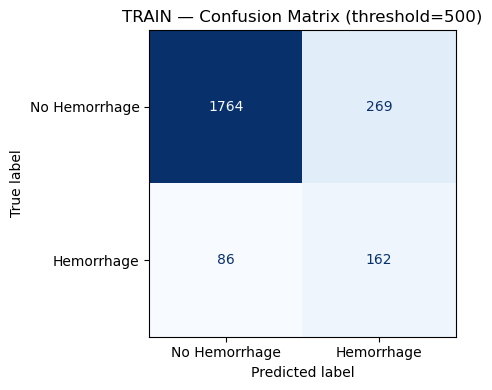


─────────────────────────────────────────────
  VAL  (threshold = 500)
─────────────────────────────────────────────
  Accuracy  : 0.8631
  Precision : 0.5000
  Recall    : 0.8788
  F1 Score  : 0.6374


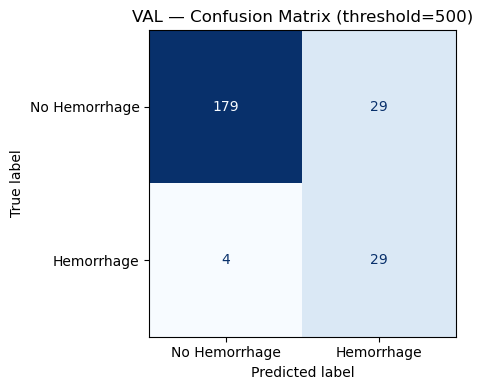


─────────────────────────────────────────────
  TEST  (threshold = 500)
─────────────────────────────────────────────
  Accuracy  : 0.7740
  Precision : 0.2958
  Recall    : 0.5676
  F1 Score  : 0.3889


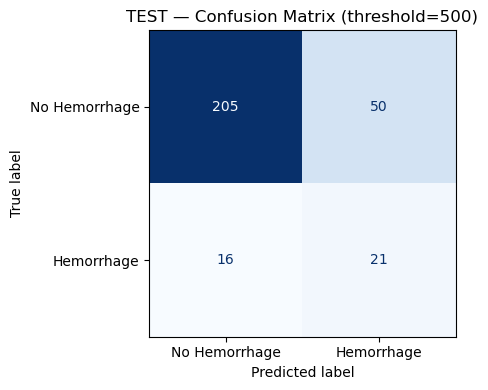

[1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,


In [8]:
# ─────────────────────────────────────────────
# 8. FINAL EVALUATION — all splits
#    Using the best threshold from validation
# ─────────────────────────────────────────────

def evaluate(y_true, mask_sums, threshold, split_name):
    y_pred = [int(s > threshold) for s in mask_sums]

    acc  = accuracy_score(y_true,  y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true,    y_pred, zero_division=0)
    f1   = f1_score(y_true,        y_pred, zero_division=0)

    print(f"\n{'─'*45}")
    print(f"  {split_name}  (threshold = {threshold})")
    print(f"{'─'*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")

    # Confusion matrix
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Hemorrhage", "Hemorrhage"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{split_name} — Confusion Matrix (threshold={threshold})")
    plt.tight_layout()
    plt.show()

    return y_pred


evaluate(train_true, train_sums, best_threshold, "TRAIN")
evaluate(val_true,   val_sums,   best_threshold, "VAL")
evaluate(test_true,  test_sums,  best_threshold, "TEST")

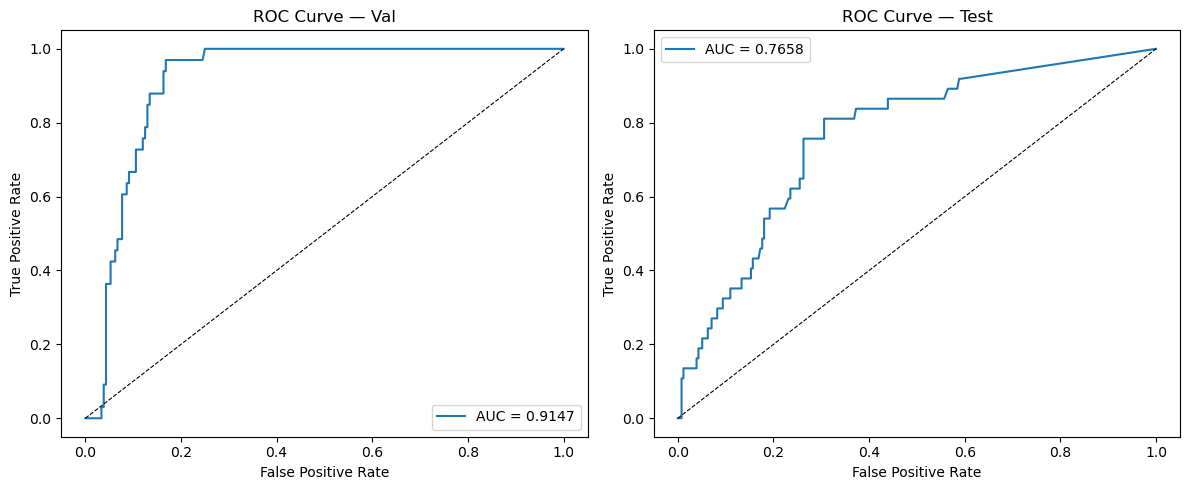

In [9]:
# ─────────────────────────────────────────────
# 9. ROC CURVE — Val & Test
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_true, scores, label) in zip(
    axes,
    [(val_true, val_sums, "Val"), (test_true, test_sums, "Test")]
):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc         = roc_auc_score(y_true, scores)
    ax.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    ax.plot([0,1],[0,1], "k--", linewidth=0.8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {label}")
    ax.legend()

plt.tight_layout()
plt.show()

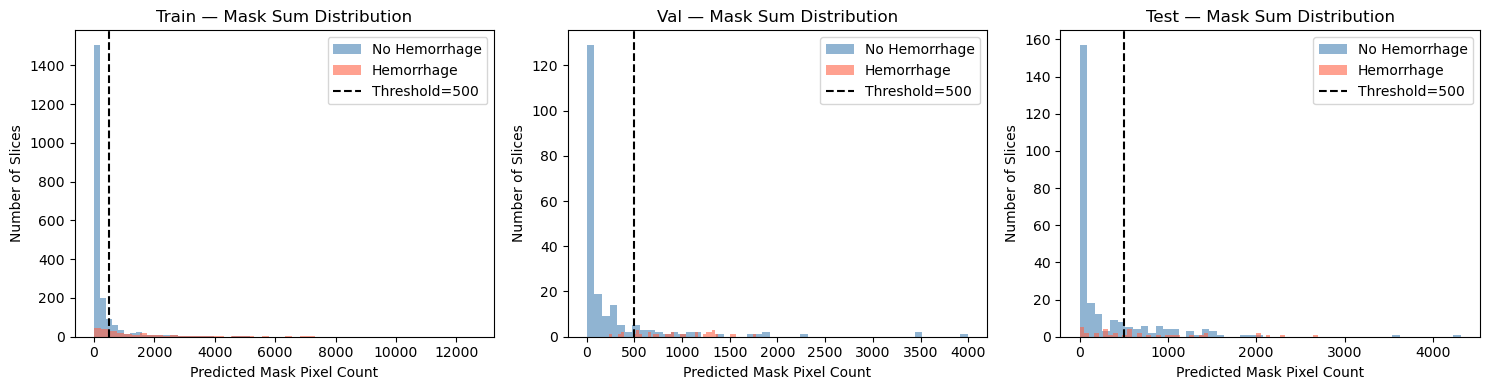

In [10]:
# ─────────────────────────────────────────────
# 10. MASK SUM DISTRIBUTION
#     Visualise how mask sums separate classes
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (y_true, sums, label) in zip(
    axes,
    [(train_true, train_sums, "Train"),
     (val_true,   val_sums,   "Val"),
     (test_true,  test_sums,  "Test")]
):
    pos_sums = [s for s, y in zip(sums, y_true) if y == 1]
    neg_sums = [s for s, y in zip(sums, y_true) if y == 0]

    ax.hist(neg_sums, bins=50, alpha=0.6, label="No Hemorrhage", color="steelblue")
    ax.hist(pos_sums, bins=50, alpha=0.6, label="Hemorrhage",    color="tomato")
    ax.axvline(best_threshold, color="black", linestyle="--", label=f"Threshold={best_threshold}")
    ax.set_xlabel("Predicted Mask Pixel Count")
    ax.set_ylabel("Number of Slices")
    ax.set_title(f"{label} — Mask Sum Distribution")
    ax.legend()

plt.tight_layout()
plt.show()